In [34]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from collections import Counter




plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 1. 데이터 로드 + 기본 탐색 + 파생변수 생성

In [35]:
df = pd.read_csv('./data/reviews_joined_all_matched.csv')

C:\Users\Playdata\AppData\Local\Temp\ipykernel_5428\1931989018.py:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/reviews_joined_all_matched.csv')


In [36]:
df.columns

Index(['appid', 'recommendationid', 'steamid', 'num_games_owned',
       'num_reviews_author', 'playtime_forever', 'playtime_last_two_weeks',
       'playtime_at_review', 'deck_playtime_at_review', 'last_played',
       'language', 'review', 'timestamp_created', 'timestamp_updated',
       'voted_up', 'votes_up', 'votes_funny', 'weighted_vote_score',
       'comment_count', 'steam_purchase', 'received_for_free',
       'written_during_early_access', 'developer_response',
       'timestamp_dev_responded', 'primarily_steam_deck', 'appid_1',
       'game_name', 'genre'],
      dtype='object')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030656 entries, 0 to 1030655
Data columns (total 28 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   appid                        1030656 non-null  int64  
 1   recommendationid             1030656 non-null  int64  
 2   steamid                      1030656 non-null  int64  
 3   num_games_owned              1030656 non-null  int64  
 4   num_reviews_author           1030656 non-null  int64  
 5   playtime_forever             1030645 non-null  float64
 6   playtime_last_two_weeks      1030645 non-null  float64
 7   playtime_at_review           1030656 non-null  int64  
 8   deck_playtime_at_review      19544 non-null    float64
 9   last_played                  1030645 non-null  float64
 10  language                     1030656 non-null  object 
 11  review                       1027088 non-null  object 
 12  timestamp_created            1030656 non-n

In [38]:
df.loc[0]

appid                                                                    2139460
recommendationid                                                       199685023
steamid                                                        76561198220582271
num_games_owned                                                               23
num_reviews_author                                                             1
playtime_forever                                                         15240.0
playtime_last_two_weeks                                                      0.0
playtime_at_review                                                         15240
deck_playtime_at_review                                                      NaN
last_played                                                         1748034106.0
language                                                                 turkish
review                         oyunu kurduk eyv oynadık vs zaten türk ü bırak...
timestamp_created           

In [39]:
df.isna().sum()

appid                                0
recommendationid                     0
steamid                              0
num_games_owned                      0
num_reviews_author                   0
playtime_forever                    11
playtime_last_two_weeks             11
playtime_at_review                   0
deck_playtime_at_review        1011112
last_played                         11
language                             0
review                            3568
timestamp_created                    0
timestamp_updated                    0
voted_up                             0
votes_up                             0
votes_funny                          0
weighted_vote_score                  0
comment_count                        0
steam_purchase                       0
received_for_free                    0
written_during_early_access          0
developer_response             1027150
timestamp_dev_responded        1027150
primarily_steam_deck                 0
appid_1                  

In [40]:
df.describe()

,appid,recommendationid,steamid,num_games_owned,num_reviews_author,playtime_forever,playtime_last_two_weeks,playtime_at_review,deck_playtime_at_review,last_played,timestamp_created,timestamp_updated,votes_up,votes_funny,weighted_vote_score,comment_count,timestamp_dev_responded,appid_1
count,1.030656e+06,1.030656e+06,1.030656e+06,1.030656e+06,1.030656e+06,1.030645e+06,1.030645e+06,1.030656e+06,19544.000000,1.030645e+06,1.030656e+06,1.030656e+06,1.030656e+06,1.030656e+06,1.030656e+06,1.030656e+06,3.506000e+03,1.030656e+06
mean,1.246007e+06,2.078202e+08,7.656120e+16,5.589029e+01,9.407134e+00,1.421312e+04,4.750142e+02,1.179464e+04,1883.487055,1.762456e+09,1.760941e+09,1.761054e+09,6.485481e-01,1.244169e-01,5.027320e-01,4.645294e-02,1.759162e+09,1.246007e+06
std,8.606580e+05,4.897537e+06,6.086190e+08,1.973416e+02,6.927022e+01,3.357524e+04,1.155320e+03,3.145326e+04,5554.090679,1.173887e+07,4.747926e+06,4.725906e+06,1.345458e+01,3.082606e+00,2.275669e-02,6.260744e-01,4.410209e+06,8.606580e+05
min,4.400000e+02,1.994023e+08,7.656120e+16,0.000000e+00,1.000000e+00,5.000000e+00,0.000000e+00,5.000000e+00,1.000000,1.345532e+09,1.752096e+09,1.752096e+09,0.000000e+00,0.000000e+00,1.352486e-01,0.000000e+00,1.752181e+09,4.400000e+02
25%,5.268700e+05,2.032641e+08,7.656120e+16,0.000000e+00,1.000000e+00,1.440000e+03,0.000000e+00,8.080000e+02,46.000000,1.761593e+09,1.756657e+09,1.756828e+09,0.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,1.755116e+09,5.268700e+05
50%,1.172470e+06,2.081491e+08,7.656120e+16,0.000000e+00,3.000000e+00,4.408000e+03,0.000000e+00,2.723000e+03,276.000000,1.765687e+09,1.762017e+09,1.762260e+09,0.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,1.759032e+09,1.172470e+06
75%,1.771300e+06,2.122663e+08,7.656120e+16,5.100000e+01,8.000000e+00,1.229500e+04,3.620000e+02,9.001000e+03,1462.000000,1.767210e+09,1.764576e+09,1.764617e+09,0.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,1.763067e+09,1.771300e+06
max,3.241660e+06,2.152632e+08,7.656120e+16,3.370000e+04,1.974800e+04,2.457680e+06,3.460800e+04,2.416117e+06,157407.000000,1.767652e+09,1.767650e+09,1.767651e+09,5.763000e+03,1.425000e+03,9.897801e-01,2.580000e+02,1.767650e+09,3.241660e+06


In [41]:
# 결측치 비율(상위 20개만)
na_rate = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
print("\n결측치 비율(%) TOP20")
print(na_rate.head(20))


결측치 비율(%) TOP20
timestamp_dev_responded    99.66
developer_response         99.66
deck_playtime_at_review    98.10
review                      0.35
last_played                 0.00
playtime_forever            0.00
playtime_last_two_weeks     0.00
steamid                     0.00
num_games_owned             0.00
num_reviews_author          0.00
recommendationid            0.00
appid                       0.00
language                    0.00
playtime_at_review          0.00
timestamp_created           0.00
timestamp_updated           0.00
votes_funny                 0.00
weighted_vote_score         0.00
voted_up                    0.00
votes_up                    0.00
dtype: float64


- 결측치 0으로 대체

In [42]:
df['playtime_forever'] = df['playtime_forever'].fillna(0)
df['playtime_last_two_weeks'] = df['playtime_last_two_weeks'].fillna(0)
df['deck_playtime_at_review'] = df['deck_playtime_at_review'].fillna(0)
df['last_played'] = df['last_played'].fillna(0)
df['review'] = df['review'].fillna('N')
df['developer_response'] = df['developer_response'].fillna('N')
df['timestamp_dev_responded'] = df['timestamp_dev_responded'].fillna(0)

In [43]:
# 중복 행 개수
print("\n중복 행 개수:", df.duplicated().sum())


중복 행 개수: 0


- 타겟 변수 churn 생성

In [ ]:
review_dt = pd.to_datetime(df["timestamp_created"], unit="s")
last_dt   = pd.to_datetime(df["last_played"], unit="s")

df["days_after_review"] = (last_dt - review_dt).dt.days

df["churn"] = (df["days_after_review"] < 30).astype(int)

# 예외 처리
df.loc[df["last_played"] == 0, "churn"] = 1
df.loc[df["days_after_review"] < 0, "churn"] = 1

# 분포 확인
print(df["churn"].value_counts(dropna=False))
print("이탈률(%) =", round(df["churn"].mean() * 100, 2))
df[["timestamp_created","last_played","days_after_review","churn"]].head(5)

churn
1    612313
0    418343
Name: count, dtype: int64
이탈률(%) = 59.41


,timestamp_created,last_played,days_after_review,churn
0,1752389967,1.748034e+09,-51,1
1,1752389691,1.755746e+09,38,0
2,1752389204,1.755124e+09,31,0
3,1752388914,1.755366e+09,34,0
4,1752388911,1.752985e+09,6,1


- 장르 기반 파생변수 is_ending_genre 생성

In [45]:
ending_genre = [
  "Visual Novel",
  "Interactive Fiction",
  "Walking Simulator",
  "Story Rich",
  "Adventure",
  "Puzzle",
  "Horror",
  "Mystery",
  "Psychological Horror",
  "Narrative"
]

genre_col = "genre"

# 포함 여부(부분일치)
pattern = "|".join([g for g in ending_genre])
df["is_ending_genre"] = df[genre_col].fillna("").astype(str).str.contains(pattern, regex=True).astype(int)

print(df["is_ending_genre"].value_counts())
print("클리어형 추정 비율(%) =", round(df["is_ending_genre"].mean() * 100, 2))


is_ending_genre
1    527005
0    503651
Name: count, dtype: int64
클리어형 추정 비율(%) = 51.13


- good_review 생성

In [46]:
# 1) 언어별 키워드 사전
# - phrases: 문장/구문(부분일치 OK)
# - words: 단어성 키워드(라틴권은 단어경계 \b 적용)
# - neg: 부정 구문(걸리면 good=0으로 처리)
# - boundary: words에 \b를 붙일지 여부 (중국어/일본어/태국어/한국어는 보통 False)
LEXICON = {
    # English
    "english": {
        "phrases": [
            r"highly recommend(?:ed)?",
            r"definitely recommend",
            r"worth (?:buying|it|the money|the time)",
            r"great game",
            r"amazing game",
            r"awesome game",
            r"best game(?:s)?",
        ],
        "words": [
            r"awesome", r"amazing", r"great", r"excellent", r"fantastic", r"incredible",
            r"masterpiece", r"perfect", r"love", r"fun", r"enjoy", r"recommend", r"worth",
        ],
        "neg": [
            r"not\s+good", r"not\s+great", r"not\s+worth",
            r"(?:do\s*not|don't|dont)\s+recommend",
            r"(?:do\s*not|don't|dont)\s+buy",
            r"can't\s+recommend|cant\s+recommend",
            r"avoid\b", r"refund\b",
        ],
        "boundary": True,
    },

    # Spanish (Spain) + LatAm는 같이 처리
    "spanish": {
        "phrases": [r"muy bueno", r"vale la pena", r"lo recomiendo", r"recomendad[oa]"],
        "words": [r"genial", r"excelente", r"buen[oa]", r"incre[ií]ble", r"recomiendo", r"recomendar"],
        "neg": [r"no\s+recomiendo", r"no\s+vale\s+la\s+pena", r"no\s+es\s+buen[oa]", r"no\s+merece\s+la\s+pena", r"no\s+compr(?:es|ar)"],
        "boundary": True,
    },
    "latam": {  # 라틴아메리카 스페인어
        "phrases": [r"muy bueno", r"vale la pena", r"lo recomiendo", r"recomendad[oa]"],
        "words": [r"genial", r"excelente", r"buen[oa]", r"incre[ií]ble", r"recomiendo", r"recomendar"],
        "neg": [r"no\s+recomiendo", r"no\s+vale\s+la\s+pena", r"no\s+es\s+buen[oa]", r"no\s+merece\s+la\s+pena", r"no\s+compr(?:es|ar)"],
        "boundary": True,
    },

    # Portuguese (PT / BR)
    "portuguese": {
        "phrases": [r"vale a pena", r"recomendo", r"muito bom", r"jogo (?:muito )?bom"],
        "words": [r"ótimo", r"excelente", r"incr[ií]vel", r"perfeito", r"divertido", r"recomendar"],
        "neg": [r"não\s+recomendo", r"nao\s+recomendo", r"não\s+vale\s+a\s+pena", r"nao\s+vale\s+a\s+pena", r"não\s+é\s+bom", r"nao\s+e\s+bom", r"não\s+compr(?:e|ar)", r"nao\s+compr(?:e|ar)"],
        "boundary": True,
    },
    "brazilian": {  # 브라질 포르투갈어
        "phrases": [r"vale a pena", r"recomendo", r"muito bom", r"jogo (?:muito )?bom"],
        "words": [r"ótimo", r"excelente", r"incr[ií]vel", r"perfeito", r"divertido", r"recomendar"],
        "neg": [r"não\s+recomendo", r"nao\s+recomendo", r"não\s+vale\s+a\s+pena", r"nao\s+vale\s+a\s+pena", r"não\s+é\s+bom", r"nao\s+e\s+bom", r"não\s+compr(?:e|ar)", r"nao\s+compr(?:e|ar)"],
        "boundary": True,
    },

    # German
    "german": {
        "phrases": [r"sehr gut", r"klare(?:s)? empfehlung", r"lohnt sich", r"absolut empfehl"],
        "words": [r"genial", r"toll", r"super", r"großartig", r"exzellent", r"empfehle", r"empfehlenswert"],
        "neg": [r"nicht\s+empfehl", r"lohnt\s+sich\s+nicht", r"nicht\s+gut", r"kau(?:f|ft)\s+nicht", r"kein\s+kauf"],
        "boundary": True,
    },

    # French
    "french": {
        "phrases": [r"je recommande", r"vaut le coup", r"tr[eè]s bon", r"excellent jeu"],
        "words": [r"g[eé]nial", r"excellent", r"super", r"incroyable", r"parfait", r"recommande"],
        "neg": [r"je\s+ne\s+recommande\s+pas", r"ne\s+vaut\s+pas\s+le\s+coup", r"pas\s+bon", r"n['’]achetez\s+pas", r"n['’]ach[eè]te\s+pas"],
        "boundary": True,
    },

    # Italian
    "italian": {
        "phrases": [r"lo consiglio", r"vale la pena", r"molto bello", r"gioco (?:molto )?bello"],
        "words": [r"fantastico", r"ottimo", r"eccellente", r"stupendo", r"divertente", r"consiglio", r"consigliare"],
        "neg": [r"non\s+lo\s+consiglio", r"non\s+vale\s+la\s+pena", r"non\s+[eè]\s+bello", r"non\s+compr(?:are|atelo)"],
        "boundary": True,
    },

    # Dutch
    "dutch": {
        "phrases": [r"zeker aanraden", r"de moeite waard", r"heel goed", r"geweldig spel"],
        "words": [r"geweldig", r"fantastisch", r"super", r"leuk", r"aanraden", r"aanbevelen", r"waarde"],
        "neg": [r"niet\s+aanrad", r"niet\s+de\s+moeite\s+waard", r"niet\s+goed", r"koop\s+niet"],
        "boundary": True,
    },

    # Swedish / Norwegian / Danish / Finnish
    "swedish": {
        "phrases": [r"rekommenderar", r"värt det", r"jättebra", r"riktigt bra"],
        "words": [r"fantastisk", r"grym", r"suverän", r"toppen", r"kul", r"rekommendera", r"värd"],
        "neg": [r"rekommenderar\s+inte", r"inte\s+värt", r"inte\s+bra", r"köp\s+inte"],
        "boundary": True,
    },
    "norwegian": {
        "phrases": [r"anbefaler", r"verdt det", r"kjempebra", r"veldig bra"],
        "words": [r"fantastisk", r"råbra", r"suveren", r"gøy", r"anbefale", r"verdt"],
        "neg": [r"anbefaler\s+ikke", r"ikke\s+verdt", r"ikke\s+bra", r"ikke\s+kjøp"],
        "boundary": True,
    },
    "danish": {
        "phrases": [r"anbefaler", r"v[æa]rd at", r"mega god", r"rigtig god"],
        "words": [r"fantastisk", r"fremragende", r"super", r"sjov", r"anbefale", r"v[æa]rd"],
        "neg": [r"anbefaler\s+ikke", r"ikke\s+v[æa]rd", r"ikke\s+god", r"k[oø]b\s+ikke"],
        "boundary": True,
    },
    "finnish": {
        "phrases": [r"suosittelen", r"todella hyv[äa]", r"sen arvoinen", r"hyv[äa] peli"],
        "words": [r"loistava", r"mahtava", r"erinomainen", r"hauska", r"suositella", r"arvoinen"],
        "neg": [r"en\s+suosittele", r"ei\s+kannata", r"ei\s+hyv[äa]", r"älä\s+osta"],
        "boundary": True,
    },

    # Polish / Czech / Romanian / Hungarian / Bulgarian / Greek / Ukrainian / Russian / Turkish
    "polish": {
        "phrases": [r"polecam", r"warto", r"świetna gra", r"bardzo dobra"],
        "words": [r"świetn[aey]", r"super", r"rewelacyjna", r"doskonała", r"polecić", r"warto"],
        "neg": [r"nie\s+polecam", r"nie\s+warto", r"nie\s+jest\s+dobr", r"nie\s+kupuj"],
        "boundary": True,
    },
    "czech": {
        "phrases": [r"doporu[čc]uji", r"stoj[ií]\s+za\s+to", r"skv[ěe]l[aá]", r"v[ýy]born[aá]"],
        "words": [r"super", r"skv[ěe]l", r"v[ýy]born", r"bav[ií]", r"doporu[čc]it"],
        "neg": [r"nedoporu[čc]uji", r"nestoj[ií]\s+za\s+to", r"nen[ií]\s+dobr", r"nekupuj"],
        "boundary": True,
    },
    "romanian": {
        "phrases": [r"recomand", r"merit[ăa]", r"foarte bun", r"joc (?:foarte )?bun"],
        "words": [r"excelent", r"minunat", r"super", r"recomanda", r"merit"],
        "neg": [r"nu\s+recomand", r"nu\s+merit[ăa]", r"nu\s+e\s+bun", r"nu\s+cump[ăa]ra"],
        "boundary": True,
    },
    "hungarian": {
        "phrases": [r"aj[aá]nlom", r"meg[eé]ri", r"nagyon j[oó]", r"szuper j[aá]t[eé]k"],
        "words": [r"szuper", r"fantasztikus", r"kiv[aá]l[oó]", r"nagyon", r"aj[aá]nlani", r"meg[eé]r"],
        "neg": [r"nem\s+aj[aá]nlom", r"nem\s+[eé]ri\s+meg", r"nem\s+j[oó]", r"ne\s+vedd\s+meg"],
        "boundary": True,
    },
    "bulgarian": {
        "phrases": [r"препоръч", r"много добра", r"страхотна", r"заслужава си"],
        "words": [r"страхот", r"отлич", r"супер", r"препоръч", r"шедьовър"],
        "neg": [r"не\s+препоръч", r"не\s+си\s+струва", r"не\s+е\s+доб", r"не\s+купувай"],
        "boundary": False,  # кир릴은 \b가 애매해서 단순부분일치로
    },
    "greek": {
        "phrases": [r"το\s+προτείν", r"αξίζει", r"πολύ\s+καλ", r"εξαιρετικ"],
        "words": [r"τέλει", r"φοβε", r"εξαιρετικ", r"καταπληκτικ", r"προτείν", r"αξίζ"],
        "neg": [r"δεν\s+προτείν", r"δεν\s+αξίζ", r"δεν\s+είναι\s+καλ", r"μην\s+αγοράσ"],
        "boundary": False,
    },
    "ukrainian": {
        "phrases": [r"рекоменд", r"дуже\s+хорош", r"варто", r"чудов"],
        "words": [r"відмін", r"класн", r"шедевр", r"рекоменд", r"варто"],
        "neg": [r"не\s+рекоменд", r"не\s+варто", r"не\s+хорош", r"не\s+купуй"],
        "boundary": False,
    },
    "russian": {
        "phrases": [r"рекоменд", r"очень\s+хорош", r"стоит", r"шедевр"],
        "words": [r"отлич", r"классн", r"супер", r"шедевр", r"рекоменд", r"стоит"],
        "neg": [r"не\s+рекоменд", r"не\s+стоит", r"плох", r"не\s+покупай", r"не\s+берите"],
        "boundary": False,
    },
    "turkish": {
        "phrases": [r"kesinlikle tavsiye", r"tavsiye ederim", r"çok iyi", r"mükemmel", r"harika"],
        "words": [r"güzel", r"mükemmel", r"harika", r"şahane", r"tavsiye", r"değer"],
        "neg": [r"tavsiye etmem", r"tavsiye etmiyorum", r"iyi değil", r"alma", r"almayın", r"değmez"],
        "boundary": True,
    },

    # Korean / Japanese / Chinese / Arabic / Thai / Vietnamese / Indonesian
    "koreana": {
        "phrases": [r"강추", r"완전 추천", r"강력 추천", r"갓겜", r"명작", r"존잼", r"개꿀잼", r"재밌", r"재미있"],
        "words": [r"추천", r"최고", r"꿀잼", r"재미", r"좋다", r"훌륭", r"완벽", r"감동"],
        "neg": [r"비추", r"추천\s*안", r"추천\s*하지", r"재미없", r"별로", r"최악", r"사지\s*마", r"사지마", r"환불"],
        "boundary": False,
    },
    "japanese": {
        "phrases": [r"おすすめ", r"オススメ", r"最高", r"神ゲー", r"買う価値", r"面白い", r"楽しい"],
        "words": [r"おすすめ", r"最高", r"神", r"面白", r"楽しい", r"良い", r"素晴らしい"],
        "neg": [r"おすすめしない", r"買わない方が", r"つまらない", r"面白くない", r"最悪", r"返品"],
        "boundary": False,
    },
    "schinese": {
        "phrases": [r"强烈推荐", r"非常推荐", r"值得买", r"值得入", r"很值得", r"很好玩", r"神作", r"精品"],
        "words": [r"推荐", r"值得", r"好玩", r"很好", r"优秀", r"完美", r"喜欢"],
        "neg": [r"不推荐", r"不值得", r"不好玩", r"垃圾", r"别买", r"千万别买", r"退款"],
        "boundary": False,
    },
    "tchinese": {
        "phrases": [r"強烈推薦", r"非常推薦", r"值得買", r"值得入", r"很值得", r"很好玩", r"神作", r"精品"],
        "words": [r"推薦", r"值得", r"好玩", r"很好", r"優秀", r"完美", r"喜歡"],
        "neg": [r"不推薦", r"不值得", r"不好玩", r"垃圾", r"別買", r"千萬別買", r"退款"],
        "boundary": False,
    },
    "arabic": {
        "phrases": [r"أنصح", r"ممتاز", r"رائع", r"يستحق", r"لعبة رائعة", r"ممتعة"],
        "words": [r"ممتاز", r"رائع", r"جميل", r"ممتع", r"يستحق", r"أنصح"],
        "neg": [r"لا\s+أنصح", r"لا\s+يستحق", r"سيئ", r"لا\s+تشتري", r"استرجاع"],
        "boundary": False,
    },
    "thai": {
        "phrases": [r"แนะนำ", r"ดีมาก", r"สุดยอด", r"คุ้มค่า", r"สนุกมาก", r"โคตรสนุก"],
        "words": [r"แนะนำ", r"ดี", r"สนุก", r"สุดยอด", r"คุ้ม", r"ชอบ"],
        "neg": [r"ไม่แนะนำ", r"ไม่คุ้ม", r"ไม่ดี", r"แย่", r"อย่าซื้อ", r"ขอคืนเงิน"],
        "boundary": False,
    },
    "vietnamese": {
        "phrases": [r"rất hay", r"tuyệt vời", r"đáng mua", r"đáng tiền", r"nên mua", r"khuyên dùng"],
        "words": [r"hay", r"tuyệt", r"xuất sắc", r"đáng", r"thích", r"khuyên", r"nên"],
        "neg": [r"không\s+khuyên", r"không\s+đáng", r"đừng\s+mua", r"tệ", r"chán", r"hoàn tiền"],
        "boundary": True,
    },
    "indonesian": {
        "phrases": [r"sangat bagus", r"rekomendasi", r"worth it", r"layak dibeli", r"seru banget"],
        "words": [r"bagus", r"keren", r"mantap", r"seru", r"rekomend", r"layak"],
        "neg": [r"tidak\s+rekomend", r"jangan\s+beli", r"tidak\s+layak", r"jelek", r"buruk", r"refund"],
        "boundary": True,
    },
}

# 없는 언어는 english로 fallback
DEFAULT_LANG = "english"


# 2) 정규식 빌더
def _compile_lexicon(cfg):
    boundary = cfg.get("boundary", True)

    parts_good = []
    for p in cfg.get("phrases", []):
        parts_good.append(f"(?:{p})")
    for w in cfg.get("words", []):
        if boundary:
            parts_good.append(rf"\b{w}\b")
        else:
            parts_good.append(f"(?:{w})")

    good_pat = "|".join(parts_good) if parts_good else r"$^"
    good_re = re.compile(good_pat, flags=re.UNICODE)

    neg_parts = [f"(?:{p})" for p in cfg.get("neg", [])]
    neg_pat = "|".join(neg_parts) if neg_parts else r"$^"
    neg_re = re.compile(neg_pat, flags=re.UNICODE)

    return good_re, neg_re


_COMPILED = {}
for lang, cfg in LEXICON.items():
    _COMPILED[lang] = _compile_lexicon(cfg)
_COMPILED[DEFAULT_LANG] = _COMPILED.get(DEFAULT_LANG, _compile_lexicon(LEXICON["english"]))


def add_good_flag_multilang(df, text_col="review", lang_col="language"):
    out = df.copy()

    text = out[text_col].fillna("").astype(str).str.casefold()
    lang = out[lang_col].fillna(DEFAULT_LANG).astype(str)

    good_hit = pd.Series(False, index=out.index)
    neg_hit  = pd.Series(False, index=out.index)

    for l in lang.unique():
        mask = (lang == l)
        good_re, neg_re = _COMPILED.get(l, _COMPILED[DEFAULT_LANG])

        good_hit.loc[mask] = text.loc[mask].str.contains(good_re, regex=True)
        neg_hit.loc[mask]  = text.loc[mask].str.contains(neg_re,  regex=True)

    out["good_review"] = (good_hit & (~neg_hit)).astype(int)
    return out


df_good = add_good_flag_multilang(df, text_col="review", lang_col="language")
print(df_good["good_review"].value_counts())

good_review
0    754224
1    276432
Name: count, dtype: int64


- df 갱신 및 새로 추가한 파생변수들 평균 확인

In [47]:
df = df_good.copy()

print("최종 컬럼 수:", df.shape[1])
print("churn 평균(이탈률):", round(df["churn"].mean(), 4))
print("is_ending_genre 평균:", round(df["is_ending_genre"].mean(), 4))
print("good_review 평균:", round(df["good_review"].mean(), 4))


최종 컬럼 수: 32
churn 평균(이탈률): 0.5941
is_ending_genre 평균: 0.5113
good_review 평균: 0.2682


# 2. 데이터 전처리

In [48]:
# boolean 컬럼이 있으면 0/1로 변환
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()
for c in bool_cols:
    df[c] = df[c].astype(int)

In [49]:
# target/파생 이진 컬럼은 확실히 int로
for c in ["churn", "is_ending_genre", "good_review"]:
    if c in df.columns:
        df[c] = df[c].astype(int)

In [50]:
# 숫자처럼 생겼는데 문자열인 컬럼들 안전 변환(실패하면 그대로 둠)
maybe_num = ["votes_up", "votes_funny", "comment_count", "weighted_vote_score",
             "playtime_forever", "num_games_owned", "num_reviews_author"]
for c in maybe_num:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030656 entries, 0 to 1030655
Data columns (total 32 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   appid                        1030656 non-null  int64  
 1   recommendationid             1030656 non-null  int64  
 2   steamid                      1030656 non-null  int64  
 3   num_games_owned              1030656 non-null  int64  
 4   num_reviews_author           1030656 non-null  int64  
 5   playtime_forever             1030656 non-null  float64
 6   playtime_last_two_weeks      1030656 non-null  float64
 7   playtime_at_review           1030656 non-null  int64  
 8   deck_playtime_at_review      1030656 non-null  float64
 9   last_played                  1030656 non-null  float64
 10  language                     1030656 non-null  object 
 11  review                       1030656 non-null  object 
 12  timestamp_created            1030656 non-n

- 누수 위험 컬럼들 정리

In [51]:
suspected_leaked_column = []

for c in ["last_played",
    "timestamp_created",
    "timestamp_updated",
    "timestamp_dev_responded",
    "days_after_review",
    "playtime_forever",       
    "review",                 # 텍스트 원문 대신 good_review만 쓰기
    "developer_response"]:
    if c in df.columns:
        suspected_leaked_column.append(c)

print("누수_의심_컬럼:", suspected_leaked_column)


누수_의심_컬럼: ['last_played', 'timestamp_created', 'timestamp_updated', 'timestamp_dev_responded', 'days_after_review', 'playtime_forever', 'review', 'developer_response']


- 모델용 데이터프레임 복사본 준비

In [52]:
df_model = df.copy()

# 3. EDA 및 그래프 시각화

- 상관관계 히트맵

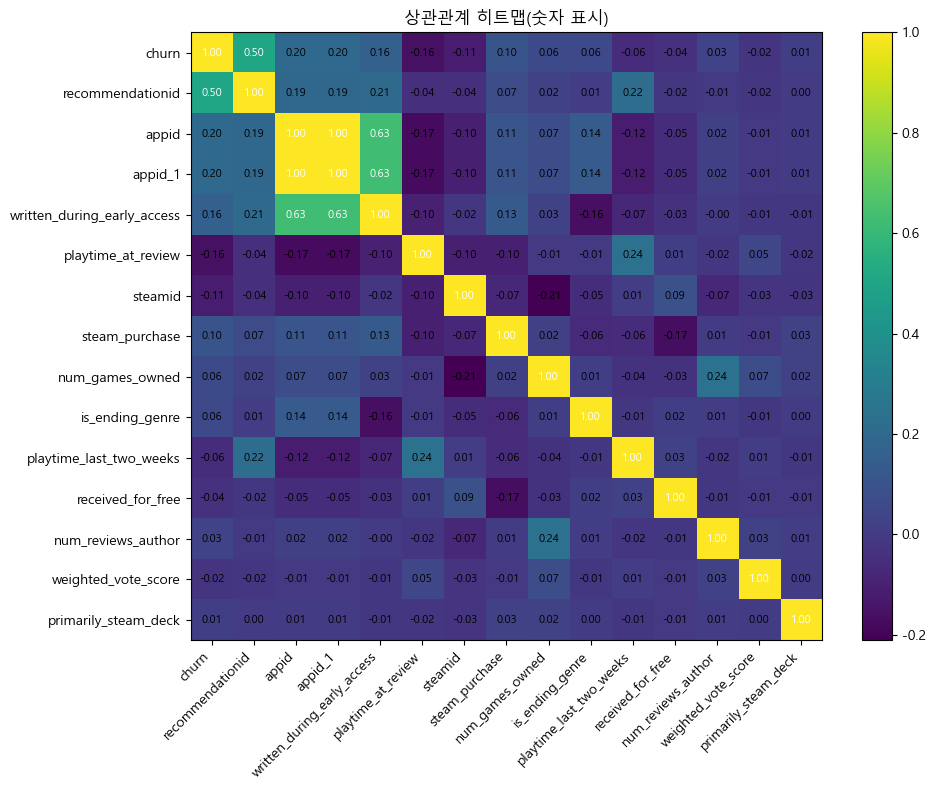


churn과 상관관계 TOP15


churn                          1.000000
recommendationid               0.502567
appid                          0.204306
appid_1                        0.204306
written_during_early_access    0.162428
steam_purchase                 0.102524
num_games_owned                0.063576
is_ending_genre                0.058385
num_reviews_author             0.032199
primarily_steam_deck           0.013090
Name: churn, dtype: float64

playtime_at_review        -0.157233
steamid                   -0.112370
playtime_last_two_weeks   -0.056371
received_for_free         -0.038070
weighted_vote_score       -0.021507
deck_playtime_at_review   -0.006333
comment_count             -0.005550
votes_up                  -0.003702
votes_funny               -0.002863
good_review                0.004084
Name: churn, dtype: float64

In [53]:
# 숫자형만
num_df = df_model.drop(columns=suspected_leaked_column, errors="ignore").select_dtypes(include=[np.number]).copy()
corr = num_df.corr(numeric_only=True)

# churn과 상관 절댓값 상위 15개만 보기
top = corr["churn"].abs().sort_values(ascending=False).head(15).index
corr_top = corr.loc[top, top]

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr_top.values, aspect="auto")
fig.colorbar(im, ax=ax)

ax.set_xticks(range(len(top)))
ax.set_yticks(range(len(top)))
ax.set_xticklabels(top, rotation=45, ha="right")
ax.set_yticklabels(top)

ax.set_title("상관관계 히트맵(숫자 표시)")

# 셀 안에 숫자 표시 (상관계수)
for i in range(corr_top.shape[0]):
    for j in range(corr_top.shape[1]):
        val = corr_top.iloc[i, j]
        # 배경색이 진하면 흰색, 연하면 검은색으로 글씨 보이게
        text_color = "white" if abs(val) > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=8)

plt.tight_layout()
plt.show()

print("\nchurn과 상관관계 TOP15")
display(corr["churn"].sort_values(ascending=False).head(10))
display(corr["churn"].sort_values(ascending=True).head(10))

- 카테고리 피처: 개수 + 이탈률 함수

In [54]:
def category_count_churn(df, col, top_n=10):
    tmp = df.copy()

    # 값이 너무 많으면 상위 top_n만, 나머지는 '기타'
    vc = tmp[col].astype(str).value_counts()
    if len(vc) > top_n:
        top_vals = vc.head(top_n).index
        tmp[col] = tmp[col].astype(str).where(tmp[col].astype(str).isin(top_vals), "기타")
    else:
        tmp[col] = tmp[col].astype(str)

    g = tmp.groupby(col)["churn"].agg(개수="count", 이탈률="mean").sort_values("개수", ascending=False)

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.bar(g.index, g["개수"])
    ax1.set_xlabel(col)
    ax1.set_ylabel("리뷰 개수")

    ax2 = ax1.twinx()
    ax2.plot(g.index, g["이탈률"] * 100, marker="o")
    ax2.set_ylabel("이탈률(%)")

    plt.title(f"{col}별 리뷰 개수 + 이탈률(%)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    display(g.assign(이탈률퍼센트=(g["이탈률"]*100).round(2)))


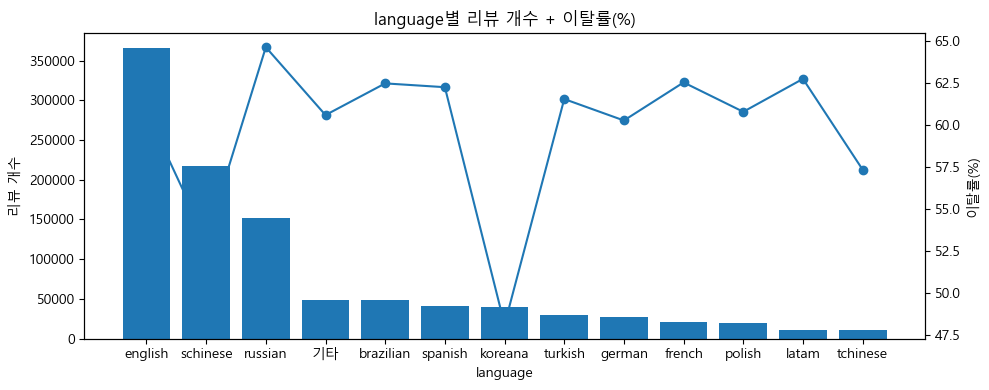

,개수,이탈률,이탈률퍼센트
language,,,
english,366172,0.607925,60.79
schinese,217108,0.531547,53.15
russian,151218,0.646246,64.62
기타,49099,0.605817,60.58
brazilian,48679,0.624684,62.47
spanish,40463,0.622420,62.24
koreana,39725,0.480931,48.09
turkish,29914,0.615364,61.54
german,27246,0.602584,60.26


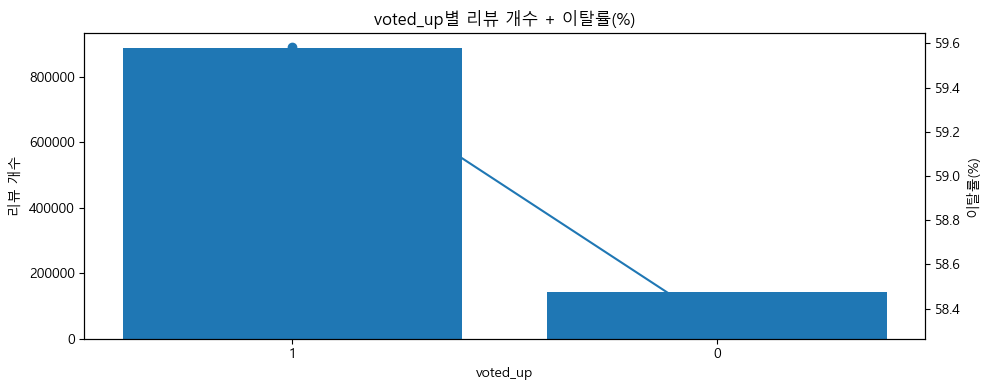

,개수,이탈률,이탈률퍼센트
voted_up,,,
1,888882,0.595828,59.58
0,141774,0.583266,58.33


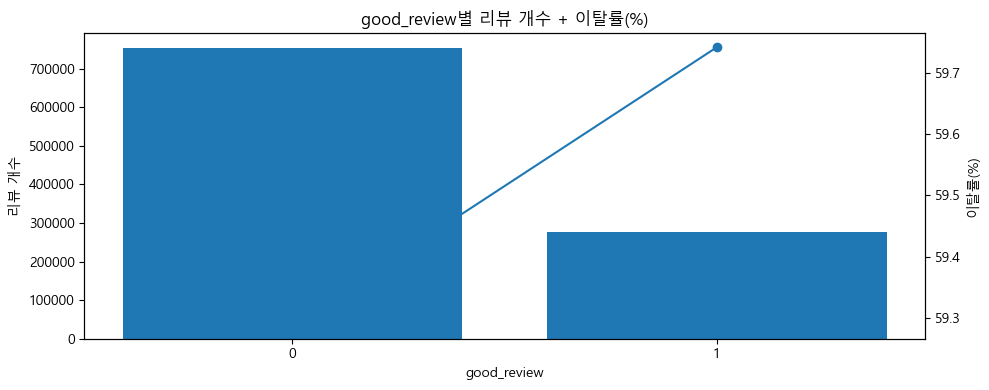

,개수,이탈률,이탈률퍼센트
good_review,,,
0,754224,0.592886,59.29
1,276432,0.597413,59.74


In [55]:
# 후보 컬럼들(데이터셋마다 이름이 다를 수 있어서 여러 후보를 넣어둠)
candidate_category = [
    "language",
    "voted_up",         # True/False인 경우 많음
    "good_review"
]

for c in candidate_category:
    if c in df_model.columns:
        category_count_churn(df_model, c, top_n=12)


교차 이탈률(%)


good_review,긍정리뷰X,긍정리뷰O
is_ending_genre,,
클리어형 아님,56.91,55.23
클리어형(추정),61.64,63.70


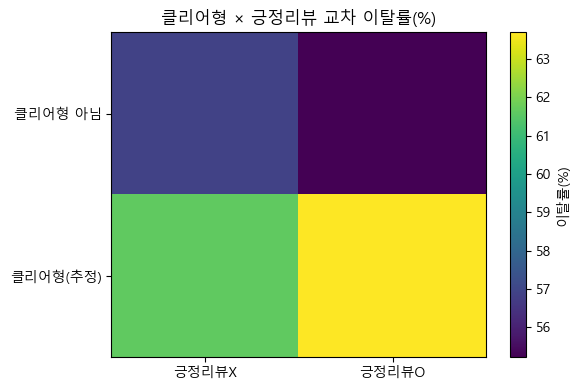

In [56]:
if ("is_ending_genre" in df_model.columns) and ("good_review" in df_model.columns):
    pivot = df_model.pivot_table(
        values="churn",
        index="is_ending_genre",
        columns="good_review",
        aggfunc="mean"
    ) * 100

    pivot.index = pivot.index.map({0:"클리어형 아님", 1:"클리어형(추정)"})
    pivot.columns = pivot.columns.map({0:"긍정리뷰X", 1:"긍정리뷰O"})

    print("교차 이탈률(%)")
    display(pivot.round(2))

    plt.figure(figsize=(6, 4))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label="이탈률(%)")
    plt.xticks(range(pivot.shape[1]), pivot.columns)
    plt.yticks(range(pivot.shape[0]), pivot.index)
    plt.title("클리어형 × 긍정리뷰 교차 이탈률(%)")
    plt.tight_layout()
    plt.show()


In [57]:
# 플레이 시간 관련 컬럼들이 말도 안되는 초헤비 유저 > 봇사용 의심 + 영향력 
# 1) 상위 99.9% 캡 
cap = df["playtime_forever"].quantile(0.999)

# 2) 캡 + log1p 처리해서 바로 덮어쓰기
cap = df_model["playtime_forever"].quantile(0.999)
df_model["playtime_forever"] = np.log1p(df_model["playtime_forever"].clip(upper=cap))

# 플레이 시간은 누수가 있어서 피쳐로는 사용 안하지만 플레이시간을 제거함으로써 다른 시간 이상치를 같이 처리 해주었다

# num_games_owned
# median: 0
# 75%: 51
# max: 33,700
# std: 197
cap = df_model["num_games_owned"].quantile(0.999)
df_model["num_games_owned"] = np.log1p(df_model["num_games_owned"].clip(upper=cap))
# num_reviews_author
# median: 3
# 75%: 8
# max: 19,748
cap = df_model["num_reviews_author"].quantile(0.999)
df_model["num_reviews_author"] = np.log1p(df_model["num_reviews_author"].clip(upper=cap))

In [58]:
df_model["num_games_owned"].head()

0    3.178054
1    0.000000
2    0.000000
3    4.430817
4    0.000000
Name: num_games_owned, dtype: float64

- appid로 그룹핑

In [59]:
gb = df_model.groupby("appid")   # 한 번만 만들어두기

g_730 = gb.get_group(730)        # 필요할 때마다 호출
g_570 = gb.get_group(570)
g_730.head()

,appid,recommendationid,steamid,num_games_owned,num_reviews_author,playtime_forever,playtime_last_two_weeks,playtime_at_review,deck_playtime_at_review,last_played,...,developer_response,timestamp_dev_responded,primarily_steam_deck,appid_1,game_name,genre,days_after_review,churn,is_ending_genre,good_review
8348,730,215258416,76561199006791796,3.091042,0.693147,10.936334,131.0,56180,0.0,1.767469e+09,...,N,0.0,0,730,Counter-Strike 2,"['Action', 'Free To Play']",-3,1,0,0
8349,730,215258403,76561198756836390,2.397895,1.386294,6.767343,682.0,868,0.0,1.767574e+09,...,N,0.0,0,730,Counter-Strike 2,"['Action', 'Free To Play']",-1,1,0,0
8350,730,215258387,76561199065711553,2.484907,0.693147,10.860901,289.0,52098,0.0,1.767647e+09,...,N,0.0,0,730,Counter-Strike 2,"['Action', 'Free To Play']",0,1,0,0
8351,730,215258355,76561198761422854,0.000000,0.693147,7.507141,461.0,1820,0.0,1.767647e+09,...,N,0.0,0,730,Counter-Strike 2,"['Action', 'Free To Play']",0,1,0,0
8352,730,215258315,76561198758514319,0.000000,0.693147,7.379632,1020.0,1602,0.0,1.767647e+09,...,N,0.0,0,730,Counter-Strike 2,"['Action', 'Free To Play']",0,1,0,0


In [60]:
def check_metrics(model, model_name, X_train, X_test, y_train, y_test, fit=True):
    if fit:
        model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    print(f"\nModel: {model_name}")

    print(f"훈련 데이터 정확도 : {accuracy_score(y_train, y_pred_train):.6f}")
    print(f"훈련 데이터 정밀도 : {precision_score(y_train, y_pred_train, zero_division=0):.6f}")
    print(f"훈련 데이터 재현율 : {recall_score(y_train, y_pred_train, zero_division=0):.6f}")
    print(f"훈련 데이터 F1-Score : {f1_score(y_train, y_pred_train, zero_division=0):.6f}")

    print(f"\n테스트 데이터 정확도 : {accuracy_score(y_test, y_pred_test):.6f}")
    print(f"테스트 데이터 정밀도 : {precision_score(y_test, y_pred_test, zero_division=0):.6f}")
    print(f"테스트 데이터 재현율 : {recall_score(y_test, y_pred_test, zero_division=0):.6f}")
    print(f"테스트 데이터 F1-Score : {f1_score(y_test, y_pred_test, zero_division=0):.6f}")


In [61]:
TARGET = "churn"

# 누수 가능성이 큰 컬럼명 키워드(리뷰 시점 이후/누적/미래정보 느낌)
UNSAFE_KEYWORDS = [
    "last_played", "days_after_review",
    "timestamp",                     # created/updated 포함(원본 타임스탬프는 제외)
    "updated",
    "playtime_forever",              # playtime_forever
    "last_two_weeks",
    "deck_playtime",
    "after_review",
    'appid_1',
    'is_ending_genre',
    'written_during_early_access',
    'playtime_at_review'
]

# ID 계열(모델에 의미 거의 없거나 과적합 위험)
ID_COLS = [
    "appid", "steamid", "recommendationid"
]

def is_unsafe_col(col: str) -> bool:
    c = col.lower()
    if col in ID_COLS:
        return True
    for k in UNSAFE_KEYWORDS:
        if k in c:
            return True
    return False

# 숫자형 후보(문자열/텍스트는 이번 STEP에서 제외:)
num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()

# SAFE 후보 = (숫자형) - (타겟) - (UNSAFE/ID)
SAFE_CANDIDATES = [
    c for c in num_cols
    if (c != TARGET) and (not is_unsafe_col(c))
]

print("SAFE 후보 피처 개수:", len(SAFE_CANDIDATES))
print("SAFE 후보 예시:", SAFE_CANDIDATES[:20])


SAFE 후보 피처 개수: 11
SAFE 후보 예시: ['num_games_owned', 'num_reviews_author', 'voted_up', 'votes_up', 'votes_funny', 'weighted_vote_score', 'comment_count', 'steam_purchase', 'received_for_free', 'primarily_steam_deck', 'good_review']


In [62]:
def select_top_features_by_corr(gdf, candidates, target="churn", top_k=12, min_var=1e-12):
    cols = [c for c in candidates if c in gdf.columns]

    # 상수/거의 상수 제거
    cols = [c for c in cols if (gdf[c].var() is not None and gdf[c].var() > min_var)]
    if len(cols) == 0:
        return []

    corr = gdf[cols + [target]].corr(numeric_only=True)[target].drop(target).dropna()
    if len(corr) == 0:
        return []

    return corr.abs().sort_values(ascending=False).head(top_k).index.tolist()


In [63]:
TOP_N_APPS = 30

top_appids = (
    df_model.groupby("appid")
    .size()
    .sort_values(ascending=False)
    .head(TOP_N_APPS)
    .index
    .tolist()
)

print("상위 30개 appid 준비 완료:", len(top_appids))


상위 30개 appid 준비 완료: 30


In [64]:
# 파라미터
MIN_ROWS = 500   # 게임별 최소 리뷰 수
TOP_K = 12       # 게임별 상관 기반 선택 피처 수

# 전처리
preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler()),
])

# 모델 후보
model_candidates = [
    ("로지스틱회귀", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
    ("랜덤포레스트", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced"
    )),
    ("히스토그래디언트부스팅", HistGradientBoostingClassifier(random_state=42)),
]


In [65]:
VERBOSE = False
results = []

gb = df_model.groupby("appid")

for appid in top_appids:
    gdf = gb.get_group(appid)

    # 최소 조건 (이건 유지)
    if len(gdf) < MIN_ROWS:
        continue
    if gdf[TARGET].nunique() < 2:
        continue

    # SAFE 피처 "전부" 사용 (해당 gdf에 존재하는 것만)
    selected = [c for c in SAFE_CANDIDATES if c in gdf.columns]

    # 상수/단일값 피처 제거: 모델 안정성↑
    selected = [c for c in selected if gdf[c].nunique(dropna=False) > 1]

    # 피처 개수 때문에 스킵하지 않기 (학습 불가만 제외)
    if len(selected) == 0:
        continue

    X = gdf[selected].copy()
    y = gdf[TARGET].astype(int).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    best_row = None

    for model_name, base_clf in model_candidates:
        pipe = Pipeline(steps=[
            ("prep", preprocess),
            ("clf", base_clf)
        ])

        pipe.fit(X_train, y_train)

        y_pred_train = pipe.predict(X_train)
        y_pred_test  = pipe.predict(X_test)

        row = {
            "appid": appid,
            "리뷰수": len(gdf),
            "이탈률(%)": round(y.mean() * 100, 2),
            "피처수": len(selected),
            "모델": model_name,

            "train_accuracy": round(accuracy_score(y_train, y_pred_train), 6),
            "train_precision": round(precision_score(y_train, y_pred_train, zero_division=0), 6),
            "train_recall": round(recall_score(y_train, y_pred_train, zero_division=0), 6),
            "train_f1": round(f1_score(y_train, y_pred_train, zero_division=0), 6),

            "test_accuracy": round(accuracy_score(y_test, y_pred_test), 6),
            "test_precision": round(precision_score(y_test, y_pred_test, zero_division=0), 6),
            "test_recall": round(recall_score(y_test, y_pred_test, zero_division=0), 6),
            "test_f1": round(f1_score(y_test, y_pred_test, zero_division=0), 6),

            "선택피처": selected,
        }

        if VERBOSE:
            print("\n" + "="*80)
            print(f"[appid={appid}] 리뷰수={len(gdf)} | 피처수={len(selected)} | 이탈률={y.mean()*100:.2f}%")
            print("선택 피처:", selected)
            check_metrics(pipe, model_name, X_train, X_test, y_train, y_test, fit=False)

        if (best_row is None) or (row["test_f1"] > best_row["test_f1"]):
            best_row = row

    results.append(best_row)

print(f"저장 완료! (상위 {TOP_N_APPS}개 중) 저장된 게임 수: {len(results)}")


저장 완료! (상위 30개 중) 저장된 게임 수: 29


In [66]:
res_df = pd.DataFrame(results)

# 리뷰수 기준으로 다시 정렬해서 보기
res_df = res_df.sort_values("리뷰수", ascending=False).reset_index(drop=True)

# 상위 30개만 출력(이미 30개만 돌렸다면 이건 그냥 안전장치)
res_df.head(30)


,appid,리뷰수,이탈률(%),피처수,모델,train_accuracy,train_precision,train_recall,train_f1,test_accuracy,test_precision,test_recall,test_f1,선택피처
0,578080,91048,41.55,11,로지스틱회귀,0.594401,0.513998,0.439158,0.473640,0.599176,0.520654,0.446412,0.480683,"[num_games_owned, num_reviews_author, voted_up..."
1,3241660,82289,86.43,11,히스토그래디언트부스팅,0.864334,0.864328,1.000000,0.927228,0.864261,0.864313,0.999930,0.927189,"[num_games_owned, num_reviews_author, voted_up..."
2,1174180,79066,55.56,11,히스토그래디언트부스팅,0.568472,0.570507,0.903216,0.699305,0.563109,0.567669,0.896085,0.695034,"[num_games_owned, num_reviews_author, voted_up..."
3,236390,69195,42.28,11,랜덤포레스트,0.679999,0.591802,0.783954,0.674459,0.522581,0.449727,0.577068,0.505501,"[num_games_owned, num_reviews_author, voted_up..."
4,413150,69082,53.28,11,히스토그래디언트부스팅,0.568570,0.591528,0.615050,0.603060,0.551639,0.577050,0.593589,0.585203,"[num_games_owned, num_reviews_author, voted_up..."
5,1091500,63260,58.67,11,히스토그래디언트부스팅,0.593404,0.593185,0.977234,0.738249,0.586390,0.589563,0.971036,0.733676,"[num_games_owned, num_reviews_author, voted_up..."
6,381210,61177,35.72,11,랜덤포레스트,0.720030,0.572990,0.848521,0.684053,0.537921,0.390630,0.524714,0.447852,"[num_games_owned, num_reviews_author, voted_up..."
7,1245620,43142,55.54,11,히스토그래디언트부스팅,0.580564,0.581754,0.870931,0.697560,0.559045,0.569127,0.847871,0.681083,"[num_games_owned, num_reviews_author, voted_up..."
8,1172470,34733,47.53,11,로지스틱회귀,0.569747,0.549572,0.524725,0.536861,0.564128,0.544023,0.512720,0.527908,"[num_games_owned, num_reviews_author, voted_up..."
9,1551360,28193,49.86,11,로지스틱회귀,0.544781,0.560655,0.401956,0.468224,0.533605,0.545274,0.389758,0.454583,"[num_games_owned, num_reviews_author, voted_up..."


In [67]:
skip_log = []

gb = df_model.groupby("appid")

for appid in top_appids:
    gdf = gb.get_group(appid)

    if len(gdf) < MIN_ROWS:
        skip_log.append((appid, "MIN_ROWS 미달", len(gdf)))
        continue

    if gdf[TARGET].nunique() < 2:
        skip_log.append((appid, "타깃 단일값(0만/1만)", len(gdf)))
        continue

    selected = select_top_features_by_corr(gdf, SAFE_CANDIDATES, target=TARGET, top_k=TOP_K)
    if len(selected) < 3:
        skip_log.append((appid, f"선택 피처 부족({len(selected)})", len(gdf)))
        continue

print("스킵된 게임 수:", len(skip_log))
skip_log[:10]  # 처음 몇 개만 보기


스킵된 게임 수: 1


[(730, '타깃 단일값(0만/1만)', 13700)]

In [68]:
import numpy as np

def f1_all_positive(p):
    return (2*p) / (1+p)

results_df = pd.DataFrame(results).copy()   

# 이탈률(%) -> p로 변환
p = results_df["이탈률(%)"] / 100.0

results_df["baseline_f1_all_1"] = p.apply(f1_all_positive)
results_df["test_f1_minus_baseline"] = results_df["test_f1"] - results_df["baseline_f1_all_1"]

results_df[[
    "appid","이탈률(%)","모델","test_f1","baseline_f1_all_1","test_f1_minus_baseline"
]].sort_values("test_f1_minus_baseline", ascending=False).head(15)


,appid,이탈률(%),모델,test_f1,baseline_f1_all_1,test_f1_minus_baseline
15,526870,58.45,히스토그래디언트부스팅,0.738616,0.737772,0.000844
26,1627720,77.60,히스토그래디언트부스팅,0.873961,0.873874,0.000087
14,1426210,81.97,히스토그래디언트부스팅,0.900966,0.900918,0.000048
21,648800,74.98,히스토그래디언트부스팅,0.857039,0.857012,0.000027
12,2001120,89.75,히스토그래디언트부스팅,0.945996,0.945982,0.000014
16,1086940,88.18,히스토그래디언트부스팅,0.937184,0.937188,-0.000004
1,3241660,86.43,히스토그래디언트부스팅,0.927189,0.927211,-0.000022
18,1771300,91.47,히스토그래디언트부스팅,0.955418,0.955450,-0.000032
27,1868140,81.23,히스토그래디언트부스팅,0.894482,0.896430,-0.001948
28,2651280,73.82,히스토그래디언트부스팅,0.847403,0.849384,-0.001981


In [69]:
from sklearn.metrics import confusion_matrix, classification_report

appid = 1771300  # 예: test_f1 높은 애
gdf = df_model[df_model["appid"] == appid].copy()

selected = [c for c in SAFE_CANDIDATES if c in gdf.columns]
selected = [c for c in selected if gdf[c].nunique(dropna=False) > 1]

X = gdf[selected]
y = gdf["churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_name, base_clf = model_candidates[0]  # 일단 첫 모델로 확인
pipe = Pipeline([("prep", preprocess), ("clf", base_clf)])
pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)
print("churn rate(test) =", y_test.mean())

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=4))


churn rate(test) = 0.9146408839779006
[[ 189  120]
 [1729 1582]]
              precision    recall  f1-score   support

           0     0.0985    0.6117    0.1697       309
           1     0.9295    0.4778    0.6312      3311

    accuracy                         0.4892      3620
   macro avg     0.5140    0.5447    0.4004      3620
weighted avg     0.8586    0.4892    0.5918      3620



In [70]:
import re

def has_unsafe_keyword(col):
    c = col.lower()
    for k in UNSAFE_KEYWORDS:
        if k in c:
            return True
    return False

# results_df["선택피처"]가 list 형태라고 가정
bad_rows = []
for i, row in results_df.iterrows():
    feats = row["선택피처"]
    bad = [f for f in feats if has_unsafe_keyword(f)]
    if bad:
        bad_rows.append((row["appid"], bad))

bad_rows[:10], len(bad_rows)


([], 0)

In [71]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, balanced_accuracy_score

# results_df = pd.DataFrame(results)

def eval_best_model_for_appid(appid):
    row = results_df[results_df["appid"] == appid].iloc[0]
    best_model_name = row["모델"]
    feats = row["선택피처"]

    gdf = df_model[df_model["appid"] == appid].copy()
    X = gdf[feats].copy()
    y = gdf[TARGET].astype(int).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # model_candidates에서 best 모델 찾기
    name2clf = {n: c for n, c in model_candidates}
    base_clf = name2clf[best_model_name]

    pipe = Pipeline([("prep", preprocess), ("clf", base_clf)])
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    print("appid =", appid)
    print("best_model =", best_model_name)
    print("churn_rate(test) =", y_test.mean())
    print("pred_positive_rate =", pred.mean())  # 예측이 얼마나 1로 쏠리는지

    print("\nconfusion_matrix")
    print(confusion_matrix(y_test, pred))

    print("\nreport")
    print(classification_report(y_test, pred, digits=4))

    print("f1(pos=1) =", f1_score(y_test, pred, pos_label=1))
    print("f1(pos=0) =", f1_score(y_test, pred, pos_label=0))
    print("macro_f1 =", f1_score(y_test, pred, average="macro"))
    print("balanced_acc =", balanced_accuracy_score(y_test, pred))

# 예시
eval_best_model_for_appid(1771300)


appid = 1771300
best_model = 히스토그래디언트부스팅
churn_rate(test) = 0.9146408839779006
pred_positive_rate = 1.0

confusion_matrix
[[   0  309]
 [   0 3311]]

report
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       309
           1     0.9146    1.0000    0.9554      3311

    accuracy                         0.9146      3620
   macro avg     0.4573    0.5000    0.4777      3620
weighted avg     0.8366    0.9146    0.8739      3620

f1(pos=1) = 0.9554176886452171
f1(pos=0) = 0.0
macro_f1 = 0.4777088443226086
balanced_acc = 0.5


c:\Users\Playdata\deep_learning\dl_venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Playdata\deep_learning\dl_venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Playdata\deep_learning\dl_venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

In [72]:


def make_churn(df, thr_days=30):
    review_dt = pd.to_datetime(df["timestamp_created"], unit="s")
    last_dt   = pd.to_datetime(df["last_played"], unit="s")

    days_after = (last_dt - review_dt).dt.days

    churn = (days_after < thr_days).astype(int)

    churn = churn.copy()
    churn[df["last_played"].fillna(0) == 0] = 1
    churn[days_after < 0] = 1
    return churn, days_after

thresholds = [7, 15, 30, 60, 90]

app_list = top_appids 

rows = []
for appid in app_list:
    gdf = df[df["appid"] == appid].copy()
    for t in thresholds:
        churn_t, _ = make_churn(gdf, thr_days=t)
        rows.append({
            "appid": appid,
            "thr": t,
            "churn_rate": churn_t.mean(),
            "n": len(gdf)
        })

rate_df = pd.DataFrame(rows)
pivot = rate_df.pivot_table(index="appid", columns="thr", values="churn_rate")
display(pivot.sort_values(30, ascending=False).head(15))


thr,7,15,30,60,90
appid,,,,,
730,1.000000,1.000000,1.000000,1.000000,1.000000
1771300,0.613404,0.763302,0.914691,1.000000,1.000000
2001120,0.781920,0.837059,0.897476,0.949315,0.971874
1086940,0.624742,0.741113,0.881781,1.000000,1.000000
3241660,0.615975,0.697444,0.864295,1.000000,1.000000
1426210,0.661900,0.746516,0.819710,0.890940,0.940650
1868140,0.587299,0.697866,0.812281,0.901417,0.943842
1627720,0.559591,0.673904,0.776004,0.869482,0.916580
648800,0.566790,0.667135,0.749776,0.839000,0.905535


In [73]:


skip = Counter()
skip_detail = []

for appid in top_appids:
    gdf = df_model[df_model["appid"] == appid].copy()

    if len(gdf) < MIN_ROWS:
        skip["MIN_ROWS"] += 1
        skip_detail.append((appid, "MIN_ROWS", len(gdf), gdf[TARGET].nunique()))
        continue

    if gdf[TARGET].nunique() < 2:
        skip["ONE_CLASS"] += 1
        skip_detail.append((appid, "ONE_CLASS", len(gdf), gdf[TARGET].nunique()))
        continue

    selected = [c for c in SAFE_CANDIDATES if c in gdf.columns]
    selected = [c for c in selected if gdf[c].nunique(dropna=False) > 1]

    if len(selected) < 1:  
        skip["NO_FEATURE"] += 1
        skip_detail.append((appid, "NO_FEATURE", len(gdf), gdf[TARGET].nunique()))
        continue

print("스킵 요약:", skip)
print("스킵 상세(앞 20개):", skip_detail[:20])


스킵 요약: Counter({'ONE_CLASS': 1})
스킵 상세(앞 20개): [(730, 'ONE_CLASS', 13700, 1)]
